In [1]:
import pandas as pd

In [2]:
df=pd.read_csv("WP.csv")
df.head()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890456,20791.31898,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.05786,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.54173,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.41744,8.059332,356.886136,363.266516,18.436525,100.341674,4.628771,0
4,9.092223,181.101509,17978.98634,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


In [3]:
df.isnull().sum()

ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64

In [4]:
df.shape

(3276, 10)

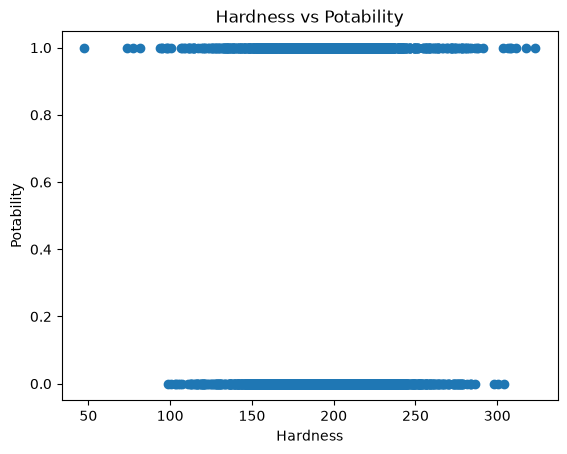

In [9]:
import matplotlib.pyplot as plt
plt.scatter(df["Hardness"],df["Potability"])
plt.xlabel("Hardness")
plt.ylabel("Potability")
plt.title("Hardness vs Potability")
plt.show()

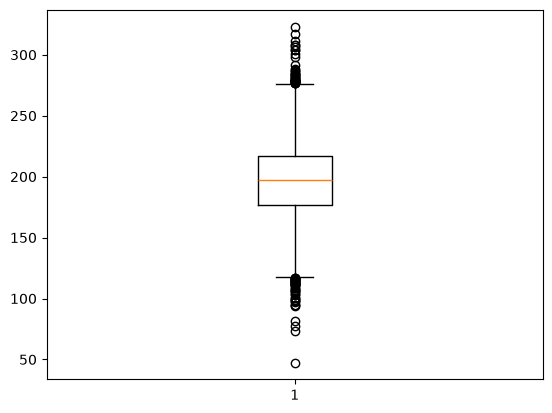

In [10]:
plt.boxplot(df["Hardness"])
plt.show()

In [11]:
#feature selection
x=df[["Hardness","Solids","Turbidity"]]
y=df["Potability"]

In [16]:
#feature scaling
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_scaled=scaler.fit_transform(x)

In [18]:
# Splitting the dataset into training and testing sets
from sklearn.model_selection import train_test_split

x_scaled_train, x_scaled_test, y_train, y_test = train_test_split(
    x_scaled, y, test_size=0.2, random_state=42
)


In [19]:
#model building
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()
lr_model=model.fit(x_scaled_train,y_train)

In [20]:
#model predictions
y_pred=lr_model.predict(x_scaled_test)

In [21]:
#model evaluations
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
accuracy=accuracy_score(y_test,y_pred)
cm=confusion_matrix(y_test,y_pred)
cr=classification_report(y_test,y_pred)
print("Accuracy:",accuracy)
print("Confusion Matrix:")
print(cm)
print("Classification Report:")
print(cr)

Accuracy: 0.6280487804878049
Confusion Matrix:
[[412   0]
 [244   0]]
Classification Report:
              precision    recall  f1-score   support

           0       0.63      1.00      0.77       412
           1       0.00      0.00      0.00       244

    accuracy                           0.63       656
   macro avg       0.31      0.50      0.39       656
weighted avg       0.39      0.63      0.48       656



c:\Users\DELL\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\DELL\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\DELL\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(averag

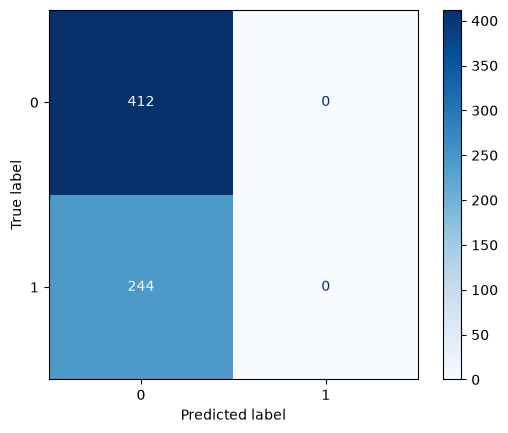

In [22]:
from sklearn.metrics import ConfusionMatrixDisplay
disp=ConfusionMatrixDisplay(confusion_matrix=cm,
                             display_labels=lr_model.classes_)
disp.plot(cmap=plt.cm.Blues)

In [23]:
#accuracy is 6280% :the model correctly classified approximately 62.80% of the test records
#About zero class
#precision is 63.00%L:out of everything the model predicts as positives, how many were positives are approximately 63.00%
#recall is 0%:out of all actual positives ,how many did the model idetified
#F1 Score is 77%:signergetic applications of precession and recall

In [25]:
import pickle
with open("lr_model.pkl","wb") as file:
    pickle.dump(lr_model,file)
print("Model saved succesfully")    

Model saved succesfully
